# Config

In [ ]:
'''#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)
'''

In [ ]:
#MOANA ONLY
'''
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
'''

In [1]:
import time

_timers = {}

def timer_start(name="default"):
    _timers[name] = time.perf_counter()

def timer_end(name="default"):
    dt = time.perf_counter() - _timers.pop(name)
    print(f"[{name}] {dt:.2f}s")
    return dt
timer_start()

In [2]:
# Cell 0 — CONFIG
#case
case_name = "402_Hide_n_seek"
experiment = "v_01"
asset_name = f"{case_name}_{experiment}"
import json
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir,
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")

set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
frames_for_cam_poses = frames_for_cam_poses_dir()

frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()#used until 15 aug
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")


project_root: /workspace/project
/workspace/project True
/workspace/project/Data/402_Hide_n_seek/010_source
Case    : 402_Hide_n_seek
Video   : VID_20260815_165930783.mp4
video fps: 30.000
total_frames 7655


In [3]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": False,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : True,
    "PROJECTION_MAP": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

# AI First Pass
## Gem, vid to text

In [10]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini_v02 import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")



re_caching video
The video begins with the seeker initiating a game of hide-and-seek in a spacious backyard garden. The camera focuses on the patio area with wooden chairs and a large potted plant before panning to the seeker's arm as they count down from one to ten, signaling the start of the search (00:00 - 00:32).

After completing the countdown, the seeker begins exploring the garden, following rustling sounds. They navigate through the lush greenery and eventually discover the first hider, a woman wearing sunglasses and a black t-shirt, crouching behind a large tree trunk at the edge of the garden (00:32 - 01:05).

Continuing the search, the seeker walks along a narrow garden path surrounded by dense bushes. Guided by more giggles and noises, they head towards a patch of purple flowers and find the second hider, an older blonde woman in a blue shirt, smiling and waving from behind a bush (01:05 - 01:37).

The seeker then moves towards a wooden shed in the garden. Suspecting someon

In [4]:
#2d ANALYSIS - JUST GPS now!
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
print(analysis_2d_for_decisions)

{'GPS_signal': 'no'}


## Producer 1

In [6]:
Question = "Make a video summary of this video and show where each person was hiding"

In [13]:
#PRODUCER DRAFT 1
from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft")


[17:08:51 +  0.00s] run_producer_agent: start
[17:08:51 +  0.00s] thread: start
[17:08:51 +  0.00s] event loop: created
[17:08:51 +  0.00s] query: start


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


[17:09:01 + 10.24s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=16446 cache_read=0
[17:09:01 + 10.24s] turn 1 content blocks: ['ThinkingBlock']
[17:09:01 + 10.24s] thinking:
Drafting the JSON now: the video is about 4:16 with a single wearer-mounted camera, no GPS so I'll use BEV_MAP, and I need recon camera poses plus tracking given the long footage. I'm structuring the beats as establisher, countdown trigger, five discovery events, map, and aftermath, while keeping an eye on R1.9 non-overlap and using auto_select with search windows since no fps is given.
[17:09:35 + 43.50s] turn 2 usage (claude-opus-5): in=2 out=3 cache_write=16446 cache_read=0
[17:09:35 + 43.51s] turn 2 content blocks: ['ToolUseBlock']
[17:09:35 + 43.51s] tool call: Write (/workspace/project/Data/402_Hide_n_seek/012_agent_p_output/v_01/402_Hide_n_seek_paper_edit_draft.json)
[17:09:35 + 43.51s] write content:
{
  "case_name": "402_Hide_n_seek",
  "brief": "Make a video summary of this video and show where e

In [5]:
# DRAFT TIDY UP
# Re-run this cell on its own to regenerate the HTML/flags after editing and correct mistakes
import importlib
import json
import render_paper_edit
importlib.reload(render_paper_edit)
from render_paper_edit import render_and_save, derive_and_save_flags, paper_edit_path
try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
except NameError:
    paper_edit_json_path = paper_edit_path()

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(
    paper_edit_json_path, producer_flags.keys(), fps=fps,
    gps_signal=analysis_2d_for_decisions.get("GPS_signal"),
)
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
flags.update(producer_output_flags)  # Producer owns MENU_KEYS; the rest stay operator-set
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))



=== Rendered HTML ===
  /workspace/project/Data/402_Hide_n_seek/012_agent_p_output/v_01/402_Hide_n_seek_draft_paper_edit.html

=== Derived flags (from 402_Hide_n_seek_draft_flags.json) ===
{
  "TRACKING": true,
  "RECON_CAM_POSES": true,
  "RECON_3D": false,
  "GOOGLE_MAP": false,
  "BEV_MAP": true,
  "PROJECTION_MAP": false,
  "MASK_OVERLAYS": true,
  "MULTICAM": false
}


# Tracking

In [8]:
# TRACKING SAM3 PIPELINE

if flags["TRACKING"]:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3
  
    analysis_2d_for_decisions.update (track_subject_sam3(video_path)) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)
else:
    print("Cell disabled")


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


accessing data
initialising tracking (local SAM3)


/workspace/project/Models/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/vscode/.local/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-08-15 18:24:01,521 2367786 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-08-15 18:24:01,522 2367786 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-08-15 18:24:01,523 2367786 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-08-15 18:24:08,267 2367786 sam3

[local SAM3] model loaded in 10.9s
[person] requested 56-65s -> keyframe-aligned start frame 1674


frame loading (OpenCV) [rank=0]: 100%|██████████| 275/275 [00:01<00:00, 263.98it/s]
INFO 2026-08-15 18:24:22,704 2367786 sam3_base_predictor.py: 146: started new session c391c405-3e30-4abe-a59f-38cbf727f0c2
propagate_in_video: 100%|██████████| 275/275 [00:57<00:00,  4.80it/s]
INFO 2026-08-15 18:25:21,863 2367786 sam3_base_predictor.py: 305: propagation ended in session c391c405-3e30-4abe-a59f-38cbf727f0c2
INFO 2026-08-15 18:25:22,059 2367786 sam3_base_predictor.py: 409: removed session c391c405-3e30-4abe-a59f-38cbf727f0c2


...

[the_barbecue_grill] requested 150-156s -> keyframe-aligned start frame 4492


frame loading (OpenCV) [rank=0]: 100%|██████████| 183/183 [00:00<00:00, 270.52it/s]
INFO 2026-08-15 18:33:06,740 2367786 sam3_base_predictor.py: 146: started new session 78c15d7d-10e4-436e-9266-95d22d6e57cd
propagate_in_video: 100%|██████████| 183/183 [00:31<00:00,  5.74it/s]
INFO 2026-08-15 18:33:38,969 2367786 sam3_base_predictor.py: 305: propagation ended in session 78c15d7d-10e4-436e-9266-95d22d6e57cd
INFO 2026-08-15 18:33:39,137 2367786 sam3_base_predictor.py: 409: removed session 78c15d7d-10e4-436e-9266-95d22d6e57cd


[the_large_hedge] requested 241-251s -> keyframe-aligned start frame 7200


frame loading (OpenCV) [rank=0]: 100%|██████████| 323/323 [00:01<00:00, 232.39it/s]
INFO 2026-08-15 18:33:48,306 2367786 sam3_base_predictor.py: 146: started new session 22686f18-f2c6-459a-a8d7-f98fd7985b06
propagate_in_video: 100%|██████████| 323/323 [01:24<00:00,  3.83it/s]
INFO 2026-08-15 18:35:12,999 2367786 sam3_base_predictor.py: 305: propagation ended in session 22686f18-f2c6-459a-a8d7-f98fd7985b06
INFO 2026-08-15 18:35:13,180 2367786 sam3_base_predictor.py: 409: removed session 22686f18-f2c6-459a-a8d7-f98fd7985b06


{'GPS_signal': 'no', 'person-1': {'Subject_frames_present': [1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948], 'subject_first_frame': 1804, 'subject_last_frame': 1948, 'subject_du

In [ ]:
#TRACKING SAM3 MANUAL controls
manual_sam = False
if manual_sam == True:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
    analysis_2d_for_decisions.update (run_sam3_manual(video_path, "man")) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)


In [9]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'person-1': {'Subject_frames_present': [1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948], 'subject_first_frame': 1804, 'subject_last_frame': 1948, 'subject_du

## Filter and store tracking data in analysis 2D

In [12]:
#Analysis 2D
from D_2d_analysis import analysis_2d_from_masks, analysis_2d_gemvsSAM
from render_paper_edit import paper_edit_path
from pprint import pprint

try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
except NameError:
    paper_edit_json_path = paper_edit_path()

#noun phrases form paper edit vs masks
analysis_2d_for_decisions.update(analysis_2d_from_masks(paper_edit_json_path))  # non-person subjects, from mask folders
#Gemini people from paper edit  VS sam csv
#analysis_2d_for_decisions.update(analysis_2d_gemvsSAM())                        # gem_person_id entries, from detections.csv
pprint(analysis_2d_for_decisions)

{'GPS_signal': 'no',
 'person-1': {'Subject_frames_present': [1804,
                                         1805,
                                         1806,
                                         1807,
                                         1808,
                                         1809,
                                         1810,
                                         1811,
                                         1812,
                                         1813,
                                         1814,
                                         1815,
                                         1816,
                                         1817,
                                         1818,
                                         1819,
                                         1820,
                                         1821,
                                         1822,
                                         1823,
                                       

In [15]:
from A_Config import source_video_path
from Two2D.B_video_processing import video_dims
from Two2D.AX_gem_SAM_matcher import gem_person_targets_lookup
from Two2D.AY_claude_crop_matcher import write_masked_crops, match_tracks_to_descriptors

_, _, fps = video_dims(source_video_path())

crops = write_masked_crops()                                  # eyeball these first
match_results = match_tracks_to_descriptors(crops_by_track=crops, fps=fps)

analysis_2d_for_decisions.update(analysis_2d_gemvsSAM(
    gem_person_targets=gem_person_targets_lookup(fps),         # beat_ids only
    match_results=match_results,                               # crops, not box IoU
))


[person-1] 3 crop(s) from 145 masked frames
[person-10] 3 crop(s) from 250 masked frames
[person-11] 3 crop(s) from 190 masked frames
[person-12] 3 crop(s) from 162 masked frames
[person-13] 3 crop(s) from 16 masked frames
[person-2] 3 crop(s) from 31 masked frames
[person-3] 3 crop(s) from 112 masked frames
[person-4] 3 crop(s) from 9 masked frames
[person-5] 3 crop(s) from 133 masked frames
[person-6] 3 crop(s) from 96 masked frames
[person-7] 3 crop(s) from 3 masked frames
[person-8] 3 crop(s) from 82 masked frames
[person-9] 3 crop(s) from 7 masked frames


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


person-1 (Woman in black t-shirt, khaki pants, and sunglasses) -> [1]


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


person-2 (Older woman with blonde hair in a blue short-sleeved shirt) -> [3]


...

person-6 (Young girl in green dress holding stuffed animals) -> [11]


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


person-7 (Teenage girl on the left in white t-shirt) -> [10, 12]


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


person-8 (Teenage girl on the right in white t-shirt) -> [10, 12]


In [ ]:
#mask checker (overlays)
mask_check = False
if mask_check ==True:
    
    print(masks_dir)
    from Two2D.W_video_editor import video_overlay_edit
    for i, mask in enumerate(p for p in masks_dir.iterdir() if p.is_dir()):
        video = video_overlay_edit(video_path, 0, 609, mask, 0,609, name = f"overlay_tst_{mask.name}")
    

/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

...

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

# RECON
## Frame Selection

In [23]:
#FRAME SELECTION POSES - Frame selection to make the cam poses
if flags["RECON_CAM_POSES"] == True and flags["FRAME_SELECTION"] == True:
    from render_paper_edit import recon_window_frames
    start_cam_recon , end_cam_recon = recon_window_frames(paper_edit_json_path=None, fps=None, flag="RECON_CAM_POSES")
    capacity = 200
    recon_dur = end_cam_recon - start_cam_recon
    cam_recon_interframe_interval =   (recon_dur+capacity-1) // capacity
    print("interval" , cam_recon_interframe_interval)

    # Parameters
    fps = fps
    interval     = cam_recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = fps/2     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        video_path = str(video_path),
        output_dir    = str(frames_for_cam_poses),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_cam_recon,
        end_frame    = end_cam_recon
    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
else:
    print("Cell disabled")

RECON_CAM_POSES: 0-232s @ 30.0fps
interval 35
Video   : VID_20260815_165930783.mp4
          30 fps · 7655 frames · 255.4s
Range   : frames 0-6960 (6960 frames)
Sampling: every 35 frames (1.1677318310472458s) → 199 candidates
Window  : ±14 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 6960/6960 [00:25<00:00, 273.52fr/s]


Selected: 199 frames  (125 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 6960/6960 [00:14<00:00, 490.31fr/s]

Log     : /workspace/project/Data/402_Hide_n_seek/020_frames_for_cam_poses/v_01/selection_log.json
Sharpness (at 25% res): min 4 · mean 4270 · max 18948

2 frames written to /workspace/project/Data/402_Hide_n_seek/020_frames_for_recon/v_01


In [20]:
print(flags)

{'VID_TO_TEXT': True, 'TRACKING': True, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': True, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION_MAP': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': True, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


In [19]:
#FRAMES FOR RECON SELECTION - Frame selection to make the recon
if flags["RECON_3D"] == True :
    from render_paper_edit import recon_window_frames
    start_3D_recon , end_3D_recon = recon_window_frames(paper_edit_json_path=None, fps=None, flag="RECON_3D")
    capacity = 200
    recon_dur = end_3D_recon - start_3D_recon
    cam_recon_interframe_interval =   (recon_dur+capacity-1) // capacity
    print("interval" , cam_recon_interframe_interval)

    # Parameters
    fps = fps
    interval     = cam_recon_interframe_interval/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = fps/2     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_recon),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_3D_recon, 
        end_frame    = end_3D_recon 

    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
else:
    print("Cell disabled")

Cell disabled


## VGGT OMEGA

In [26]:
import torch, gc; gc.collect(); torch.cuda.empty_cache()


In [6]:
#VGGT OMEGA 
#Decide which tool to use - based on #of frames
#if  end_3D_recon - start_3D_recon < 150:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
from run_models.E_VGGT_omega import run_vggt_omega

from A_Config import recon_for_MAP_dir, recon_for_EVENT_dir

recon_jobs = []
if flags['RECON_CAM_POSES']:
    recon_jobs.append((frames_for_cam_poses, recon_for_MAP_dir()))
if flags['RECON_3D']:
    recon_jobs.append((frames_for_recon, recon_for_EVENT_dir()))

for frames, recon_out in recon_jobs:
    run_vggt_omega(image_dir=str(frames), 
               output_dir=recon_out,checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints"
                                            / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"), 
vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
image_resolution=512, conf_thres=20.0, max_points=0, show_cam=True, )

199 frames  →  /workspace/project/Data/402_Hide_n_seek/031_Recon_MAP/v_01
Saved: /workspace/project/Data/402_Hide_n_seek/031_Recon_MAP/v_01/predictions.npz
Saved: /workspace/project/Data/402_Hide_n_seek/031_Recon_MAP/v_01/scene.glb


# POST RECON
## Processing

In [15]:
#LOAD VGGT_O recon for further processing
from Thr3D.F_post_recon_processing import Reconstruction
def PRP(recon,frames):
    frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
    rows = [recon.frame_to_row[f] for f in frame_keys]
    extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
    intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)
    R = extrinsic[:, :3, :3]
    t = extrinsic[:, :3, 3]
    cam_poses = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
    from Thr3D.F_post_recon_processing import positions_to_frame_dict
    cam_poses_model_dict = positions_to_frame_dict(cam_poses, frames)
    return cam_poses_model_dict

if flags['RECON_CAM_POSES']:
    recon_MAP = Reconstruction.load(frames_for_cam_poses, recon_for_MAP_dir() / "predictions.npz", FRAME_NAME_FMT)
    MAP_poses_dict = PRP(recon_MAP, frames_for_cam_poses)

if flags['RECON_3D']:
    recon_EVENT = Reconstruction.load(frames_for_recon, recon_for_MAP_dir()/ "predictions.npz", FRAME_NAME_FMT)
    EVENT_poses_dict = PRP(recon_EVENT, frames_for_recon)



In [ ]:
#TRANSFORM CAMERA POSES VS GPS
if flags["RECON_CAM_POSES"] == True and analysis_2d_for_decisions['GPS_signal']== 'yes':
    
    #get lat lon positions
    #get transforms to convert other things too
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
    cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, MAP_poses_dict)
else:
    print("Cell disabled")


Cell disabled


## Recon Visualisation

In [19]:
#Convert into model space and export into plys
if flags['RECON_CAM_POSES']:
    #Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
    ext = recon_MAP.preds["extrinsic"][0].clone()
    #MAKE PLYS of VGGT__O
    #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
    #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 

    _ = recon_MAP.VGGT_O_preds_to_ply_export(VGGT_O_output_dir /"MAP" / "ply" , 
                                            R=ext[:,0:3], 
                                            t=ext[:,3], 
                                            s=1)
if flags['RECON_3D']:
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
    ext = recon_EVENT.preds["extrinsic"][0].clone()
    #MAKE PLYS of VGGT__O
    #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
    #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
    _ = recon_MAP.VGGT_O_preds_to_ply_export(VGGT_O_output_dir /"EVENT" / "ply" , 
                                            R=ext[:,0:3], 
                                            t=ext[:,3], 
                                            s=1)


In [22]:
# Cell — PLY visualisation
if  flags["RECON_3D"] == True:     
    import importlib
    import F_cut3r_vis; importlib.reload(F_cut3r_vis)
    from F_cut3r_vis import visualise_cut3r
    visualisation_dir =   VGGT_O_output_dir /"EVENT" /
    visualise_cut3r(visualisation_dir)

else:
    print("cell disabled")

if  flags["RECON_CAM_POSES"] == True:     
    import importlib
    import F_cut3r_vis; importlib.reload(F_cut3r_vis)
    from F_cut3r_vis import visualise_cut3r
    visualisation_dir =   VGGT_O_output_dir /"MAP" 
    print(visualisation_dir)
    visualise_cut3r(visualisation_dir)

else:
    print("cell disabled")


cell disabled
/workspace/project/Data/402_Hide_n_seek/035_VGGT_O_output/v_01/MAP
Found 199 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 21 persistent messages

In [ ]:
#cutr point cloud render
render_PC = False
if  flags["RECON_3D"] == True and render_PC == True:
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   



## ANALYSIS 3D

In [24]:
#depth confidence statistics
if flags["RECON_CAM_POSES"] == True: 
    recon = recon_MAP
conf     = recon.preds["depth_conf"].cpu().numpy()
print("min, max confidence",conf.min(), conf.max())
print("frames, y, x",conf.shape)
print("confidence percentiles", np.percentile(conf, [5, 25, 50, 75, 95]))

from C_CSV_report import add_to_report
report_items = {
    "Depth Confidence (min)"      : conf.min(), 
    "Depth Confidence (max)"      : conf.max(),
    "Depth Confidence (mean)"     : conf.mean(),
    "Depth COnfidence percentiles" : np.percentile(conf, [5, 25, 50, 75, 95])
}
add_to_report(report_items)

min, max confidence 1.0000001 41.959248
frames, y, x (199, 384, 688)
confidence percentiles [ 1.00830829  2.34205818  4.04388022  6.05526447 11.96926975]


In [ ]:
print()

In [35]:
#multi subject positioning - NO GPS
if analysis_2d_for_decisions['GPS_signal'] == "no":
    from Q_subject_analysis import find_mask_centroids_in_model_space
    from pathlib import Path
    cv2.setLogLevel(0)
    
    subjects_positions_multi_dict = {}
    subjects_depth_std_multi_dict = {}
    for subject_slug, entry in analysis_2d_for_decisions.items():
        if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
            continue
        track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
        merged_SAMS = {}
        merged_std  = {}
        for track_dir in track_dirs:
            track_dir = Path(track_dir)
            centroids, frame_keys, depth_std_model = find_mask_centroids_in_model_space(
                recon, masks_dir = track_dir, RA=8, analyse=False
            )
            for fk, c, s in zip(frame_keys, centroids, depth_std_model):
                if np.isfinite(np.asarray(c)).all(): #subject positions can be Nan
                    merged_SAMS[fk] = c
                    merged_std[fk]  = s
        subjects_positions_multi_dict[subject_slug]  = merged_SAMS
        subjects_depth_std_multi_dict[subject_slug]  = merged_std




## get the stats done
positions
speed 
direction


In [26]:
#DELETE ONCE THE BELOW CELL IS PROVEN TO WORK
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
MULTI_PART_RECON = False
if flags["RECON_CAM_POSES"] == True and flags["RECON_3D"] ==True:
    if MULTI_PART_RECON == False:
        from Q_subject_analysis import subject_to_metric_and_gps_space
        from Thr3D.G_transforms_alignments import  recon_to_recon_transform
        R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)

        sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
            recon,
            masks_dir        = str(yolo_masks_dir),
            lat_0=lat_0, lon_0=lon_0,
            R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
            )    

        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
        _ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)
        
        print(VGGT_O_output_dir / "predictions.npz")
    else:
        print("Cell disabled")
else:
     print("Cell disabled")

Cell disabled


## MERGE INTO NON GPS

In [27]:
#METRIC and LAT LON processes spatial information about the recon and the subjects - for report and to map the subject
if flags["RECON_CAM_POSES"] == True and analysis_2d_for_decisions["GPS_signal"] == "yes" :
    from Q_subject_analysis import subject_to_metric_and_gps_space
    from Thr3D.G_transforms_alignments import  recon_to_recon_transform
    from pathlib import Path
    R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)

    subjects_real_pos_multi_dict = {}
    subjects_latlon_multi_dict   = {}
    for subject_slug, entry in analysis_2d_for_decisions.items():
        if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
            continue
        track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
        merged_real   = {}
        merged_latlon = []
        for track_dir in track_dirs:
            sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
                recon,
                masks_dir        = str(Path(track_dir)),
                lat_0=lat_0, lon_0=lon_0,
                R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
                )
            for fk, p in sub_pos_real_dict.items():
                if np.isfinite(np.asarray(p)).all():
                    merged_real[fk] = p
            merged_latlon += list(sub_latlon)
        subjects_real_pos_multi_dict[subject_slug] = merged_real
        subjects_latlon_multi_dict[subject_slug]   = sorted(merged_latlon)

    #TEMP! keep the old single-subject names alive for the cells below - first subject
    sub_pos_real_dict = next(iter(subjects_real_pos_multi_dict.values()), {})
    sub_latlon        = next(iter(subjects_latlon_multi_dict.values()), [])
    sub_pos           = np.array([sub_pos_real_dict[f] for f in sorted(sub_pos_real_dict)])

    #MAKE PLYS of VGGT__O
    #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
    #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
    _ = recon.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)
    
    print(VGGT_O_output_dir / "predictions.npz")
   
else:
     print("Cell disabled")


Cell disabled


In [ ]:
print(subjects_positions_multi_dict)

{}


(viser) Connection closed (0, 0 total)

{}


ValueError: need at least one array to concatenate

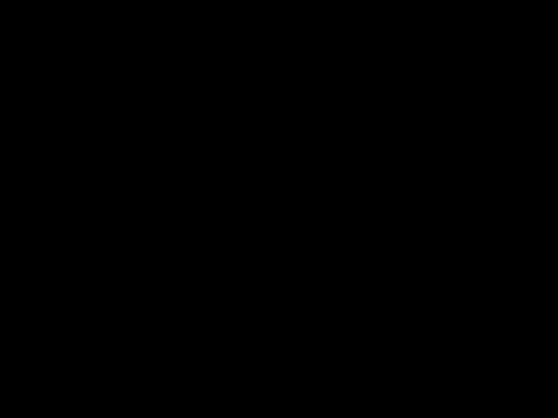

In [32]:
#graph postions 2d - NOT SURE HOW TO USE THIS! POINTLESS FOR THE REPORT!
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

subj    = subjects_real_pos_multi_dict if "subjects_real_pos_multi_dict" in dir() else subjects_positions_multi_dict
markers = ["o", "^", "s", "D", "v", "P"]
print(subj)
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

allf    = np.concatenate([np.array(sorted(d)) for d in subj.values()])
handles = []
for (slug, d), mk in zip(subj.items(), markers):
    frames = np.array(sorted(d))
    pts    = np.array([d[k] for k in frames])
    sc = ax.scatter(pts[:, 0], pts[:, 2], c=frames, cmap="viridis", marker=mk,
                    vmin=allf.min(), vmax=allf.max(), s=18)   # colour = frame number
    handles.append(Line2D([0], [0], marker=mk, ls="", color="white", label=slug))

cb = fig.colorbar(sc, ax=ax)
cb.set_label("frame", color="white")
cb.ax.yaxis.set_tick_params(color="white", labelcolor="white")

ax.legend(handles=handles, labelcolor="white", facecolor="black", edgecolor="white")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("x")
ax.set_ylabel("z)")
ax.set_title("Subject position (color = time)")


In [ ]:
print(subjects_positions_multi_dict.keys()
      )

print(subjects_positions_multi_dict['person-2']      )

dict_keys(['the_large_sword-1', 'person-2', 'person-1'])
{0: array([-0.40570003, -0.62542012,  1.56632502]), 3: array([-0.39868923, -0.51460138,  1.38538372]), 6: array([-0.50254896, -0.52507041,  1.50317002]), 9: array([-0.31476434, -0.64869273,  1.53223294]), 12: array([-0.68805384, -0.74929928,  1.63236221]), 15: array([-0.29173799, -0.64054707,  1.54091594]), 18: array([-0.49908368, -0.55254802,  1.5187658 ]), 21: array([-0.31006242, -0.63629214,  1.53233377]), 24: array([-0.435301  , -0.60741923,  1.54473406]), 27: array([-0.42000581, -0.62631928,  1.59844479]), 30: array([-0.36215582, -0.64209871,  1.57928879]), 33: array([-0.56558443, -0.59783557,  1.60052505]), 36: array([-0.47505716, -0.59954852,  1.61191663]), 39: array([-0.25611368, -0.71085836,  1.62441664]), 42: array([-0.49097606, -0.65959933,  1.57469743]), 45: array([-0.400973  , -0.6447278 ,  1.56802549]), 48: array([-0.34933505, -0.61030434,  1.6301783 ]), 51: array([-0.54292053, -0.59436688,  1.56550485]), 54: array(

{('person-2', 'person-1'): {'person-2_vs_person-1_meeting_frame': 315.0, 'person-2_vs_person-1_meeting_B_frame': 315.0, 'person-2_vs_person-1_meeting_lat_lon': (None, None), 'person-2_vs_person-1_meeting_xz': (-0.4913945434768876, 1.5681748353679934), '{{person-2_vs_person-1_meeting_distance}}': 0.10434169031781593, '{{length_units}}': 'model units', '{{camera_direction}}': None}, ('person-2', 'camera'): {'person-2_vs_camera_meeting_frame': 375.0, 'person-2_vs_camera_meeting_B_frame': 375.0, 'person-2_vs_camera_meeting_lat_lon': (None, None), 'person-2_vs_camera_meeting_xz': (-0.4190644919872284, 1.2982972860336304), '{{person-2_vs_camera_meeting_distance}}': 0.3694657926816296, '{{length_units}}': 'model units', '{{camera_direction}}': None}, ('person-1', 'the_large_sword-1'): {'person-1_vs_the_large_sword-1_meeting_frame': 279.0, 'person-1_vs_the_large_sword-1_meeting_B_frame': 279.0, 'person-1_vs_the_large_sword-1_meeting_lat_lon': (None, None), 'person-1_vs_the_large_sword-1_meetin

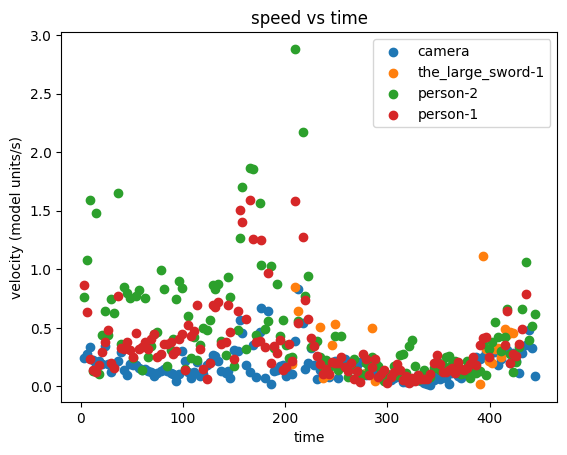

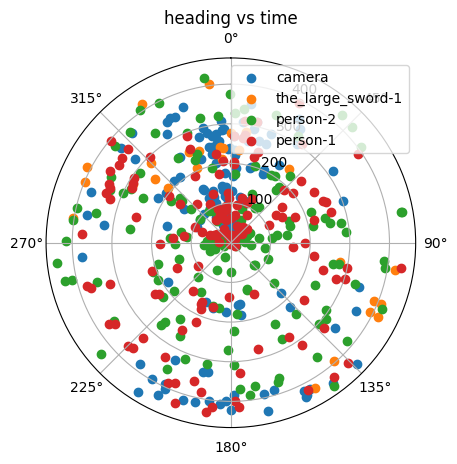

In [ ]:
##3D Graphing and analysis METRIC OR NOT
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import  meeting_calculator
from render_paper_edit import build_meeting_requests
from A_Config import has_gps_data
fps = fps
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction({"camera": cam_poses_model_dict, **subjects_positions_multi_dict}, fps)

lat, lon = (lat_0, lon_0) if has_gps_data() else (None, None)

meetings = {}
for A_dict_entry, B_dict_entry in build_meeting_requests():   # [["person-1","person-2"], ["person-1","camera"]]
    B_is_camera = B_dict_entry == "camera"
    A_real_dict = subjects_positions_multi_dict[A_dict_entry]
    B_real_dict = cam_poses_model_dict if B_is_camera else subjects_positions_multi_dict[B_dict_entry]

    meetings[(A_dict_entry, B_dict_entry)] = meeting_calculator(
        A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
        B_is_camera=B_is_camera)

print(meetings)


##TEMP TESTS

In [ ]:
print(analysis_2d_for_decisions["person-1"])

{'Subject_frames_present': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 178, 179, 180, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 2

## this will be deleted

In [ ]:
#depth based intersections checker # TEMP
#mask overlay sequence: person-1 (green) vs sword (magenta)
from Two2D.W_video_editor import apply_mask_overlay, _load_mask_bool
from A_Config import assets_dir, source_video_path
from pathlib import Path
import cv2
A_slug, B_slug = "person-1", "the_large_sword-1"
def _dirs(slug):
    e = analysis_2d_for_decisions[slug]
    return [Path(d) for d in (e.get("masks_dirs") or [e["masks_dir"]])]
A_dir, B_dir = _dirs(A_slug)[0], _dirs(B_slug)[0]
#sword is person 5
B_dir = Path("/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01/person-3")   # the sword



out_dir = assets_dir() / f"contact_check_{A_slug}_vs_{B_slug}"
out_dir.mkdir(parents=True, exist_ok=True)

frames = sorted(set(analysis_2d_for_decisions[A_slug]["Subject_frames_present"]) |
                set(analysis_2d_for_decisions[B_slug]["Subject_frames_present"]))

cap = cv2.VideoCapture(str(source_video_path()))
for f in frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, f)
    ret, frame = cap.read()
    if not ret:
        continue
    for d, colour in ((A_dir, (0, 200, 0)), (B_dir, (200, 0, 200))):
        m = _load_mask_bool(d, f)
        if m is not None:
            frame = apply_mask_overlay(frame, m, color=colour)
    cv2.imwrite(str(out_dir / f"{f:04d}.png"), frame)
cap.release()
print(out_dir, len(frames), "frames")


/workspace/project/Data/304_met_multi_4/090_assets/contact_check_person-1_vs_the_large_sword-1 421 frames


# TOUCHING TEST
## Needs work  see PHYSICS - NEW FLAGS PLAN MULTI RECON 

In [ ]:
# subject touching test
from Q_subject_analysis import contact_frames
res = contact_frames(recon, A_dir, B_dir)

r = res[386]          # your contact frame
plt.plot(list(r["A_profile"]), list(r["A_profile"].values()), "o-", label="A")
plt.plot(list(r["B_profile"]), list(r["B_profile"].values()), "o-", label="B")
plt.xlabel("depthels from seam"); plt.ylabel("depth"); plt.legend()
print(r["depth_gap"], r["fit_resid"], r["contact"])


KeyError: 386

# Rendering
## Point_cloud based

In [ ]:
#projection map
if flags["PROJECTION_MAP"] == True:
    #2D projection mapping of subject to a selected view
    from Thr3D.F_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence
    from Two2D.B_video_processing import available_frames
    #Use this to project every frame in the recon
    extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
    print(extra_indices)
    if MULTI_PART_RECON == True:
      recon = recons
      
    else: 
      recon = recon
      point_cloud_xforms = None
    subject_positions = projection_mapping_sequence(
        
        recon         = recon,
        main_idx      = 3908,
        extra_indices = extra_indices,
        #extra_indices = range (3854,4397),
        #other syntax  [400,4027, 4052, 4065],
        #extra_indices = [extra_indices], - for composite (double [[]])
        masks_dir     = str(yolo_masks_dir),

        new_view = ext ,
        
        confidence_threshold = 2
       
       )
else:
    print("Cell disabled")

Cell disabled


# PRODUCER 2

In [ ]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'the_large_sword-1': {'Subject_frames_present': [207, 208, 209, 210, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 265, 266, 279, 280, 281, 282, 283, 284, 285, 286, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425], 'subject_first_frame': 207, 'subject_last_frame': 425, 'subject_duration_frames': 218, 'continuous frame sequences': [(207, 210, 4), (237, 286, 50), (391, 425, 35)], 'best_seq_idx': 1, 'masks_dir': '/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01/the_large_sword-1', 'beat_ids': ['beat-02', 'beat-03']}, 'person-2': {'Subject_frames_present': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 6

In [ ]:
#find the cut points
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions)

PosixPath('/workspace/project/Data/304_met_multi_4/012_agent_p_output/pipetest_01/304_met_multi_4_paper_edit_draft.json')

In [ ]:
#run producer again
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision

prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt)


[21:52:37 +  0.00s] run_producer_agent: start
[21:52:37 +  0.00s] thread: start
[21:52:37 +  0.00s] event loop: created
[21:52:37 +  0.00s] query: start


Ignoring 16 permissions.allow entries from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.
Ignoring 1 permissions.additionalDirectories entry from .claude/settings.json: this workspace has not been trusted. Run Claude Code interactively here once and accept the trust dialog, or set projects["/workspace/project"].hasTrustDialogAccepted: true in /home/vscode/.claude.json.


[21:52:52 + 15.54s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=19888 cache_read=0
[21:52:52 + 15.54s] turn 1 content blocks: ['ThinkingBlock']
[21:52:52 + 15.54s] thinking:
I'm finding overlapping beats on the same camera, which violates the no-overlap rule. Rather than merging everything into one giant beat, which would destroy the edit, I think the better fix is to adjust the cut points so the boundaries no longer overlap.

Working out the frame rate from the audio spans, it looks like 25fps, so I can trim the beats to contiguous non-overlapping ranges: beat-01 from 0-4.5s, beat-02 from 4.5-8.5s, beat-03 from 8.5-16.5s, and beat-05 from 16.5-26.5s, each aligned to clean audio boundaries. I'm checking the sword detection data against these new ranges and confirming it still falls within beat-02, and person-2 tracking remains intact across the full range. For the map beat, I'll keep the BEV_MAP flag and add a synthetic frame range of 0-450 since 3D reconstruction and tracking

## Mapping

In [ ]:
#make animated map -- always writes an image sequence to assets/map_frames
# (the standard hand-off to the editor); gif/mp4 below are optional extra
# exports of the same frames. Duration is read from the Producer's MAP beat
# inside R_map_animator.main() itself, not passed in here.
if flags["GOOGLE_MAP"] == True:
    import Rendering.R_map_animator

    R_map_animator.main(
        traces=[
            {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
            {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
        ],
        api_key     = api_key,
        gif = True,
        mp4 = None
        

    )
else:
    print("Cell disabled")

Cell disabled


In [ ]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)


In [ ]:
from V_text_summary import gemini_final_report, gemini_cache_video
from A_Config import assets_dir
video_path = assets_dir() / f"{asset_name}_overlay_video.mp4"
cache =  gemini_cache_video(video_path, assets_dir(), ttl="6000s")
gemini_final_report()

In [ ]:
#Manually make ovelays
manual_overlays = False
if manual_overlays == True:
#make mask overlays and return image sequence
  from Two2D.W_video_editor import mask_compositor
  tracker = "SAM3"
  movie_start = 225*30 
  movie_end = 237*30
  mask_compositor(video_path, 
                              start = movie_start, 
                              end = movie_end, 
                              tracker= tracker, 
                              mask_start = movie_start,
                              mask_end = movie_end,
                              handles=2, 
                            color=(0, 200, 0), 
                            alpha=0.4) 


In [ ]:
#BEV SETUP
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles
from Two2D.B_video_processing import available_frames
#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)

In [ ]:
#BEV HI RES
#BEV projection mapping of subject to a selected view
#extra_indices = [23]
print(extra_indices)
recon = recon
BEV, new_view, ortho_params, BEV_path = BEV_tile_render_PM (recon, 
                     extra_indices, 
                     masks_dir=None, 
                     splat_radius=1,
                   confidence_threshold=1.05, 
                   margin_frac=0.05)  


[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 88, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 131, 134, 137, 142, 144, 146, 150, 154, 156, 158, 162, 166, 168, 171, 175, 176, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 212, 217, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 415, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447]
min depth tensor(0.0259, device='cuda:0')
torch.Size([21437256, 3])
mins, maxes and ranges -0.8426096074283123 0.21902114972472192 1.0616307571530341 -0.012640275061130524 1.9791203811764717 1.9917606562376022
scale - original 3184.045581601486


In [ ]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#n_frames is a directly controllable parameter -- not derived from duration*fps.
from P_trace_overlayer import BEV_trace_overlay
#takes BEV from assets dir
BEV_trace_overlay(
    recon,
    extra_indices,
    new_view,
    ortho_params,
    subject_positions=subjects_positions_multi_dict,
    bev_png_path = BEV_path
)


frame 0000 t_frac=0.0000 [camera] virtual_frame=0.0 pos_px=(456.9, 1073.1)
frame 0000 t_frac=0.0000 [the_large_sword-1] virtual_frame=0.0 pos_px=(346.0, 584.6)
frame 0000 t_frac=0.0000 [person-2] virtual_frame=0.0 pos_px=(206.4, 246.8)
frame 0000 t_frac=0.0000 [person-1] virtual_frame=0.0 pos_px=(228.4, 756.7)
frame 0001 t_frac=0.0040 [camera] virtual_frame=1.8 pos_px=(453.9, 1067.7)
frame 0001 t_frac=0.0040 [the_large_sword-1] virtual_frame=1.8 pos_px=(346.0, 584.6)
frame 0001 t_frac=0.0040 [person-2] virtual_frame=1.8 pos_px=(215.6, 245.9)
frame 0001 t_frac=0.0040 [person-1] virtual_frame=1.8 pos_px=(233.1, 757.4)
frame 0002 t_frac=0.0080 [camera] virtual_frame=3.6 pos_px=(451.5, 1061.2)
frame 0002 t_frac=0.0080 [the_large_sword-1] virtual_frame=3.6 pos_px=(346.0, 584.6)
frame 0002 t_frac=0.0080 [person-2] virtual_frame=3.6 pos_px=(220.8, 245.4)
frame 0002 t_frac=0.0080 [person-1] virtual_frame=3.6 pos_px=(236.4, 758.2)
frame 0003 t_frac=0.0120 [camera] virtual_frame=5.4 pos_px=(450.

PosixPath('/workspace/project/Data/304_met_multi_4/090_assets/bev_trace_frames')

In [ ]:
#Make the edited multimedia movie

import Two2D.W_video_editor
 
Two2D.W_video_editor.assemble_paper_edit(video_path)


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-02


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-03


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

PosixPath('/workspace/project/Data/304_met_multi_4/090_assets/304_met_multi_4_pipetest_01_rough_cut.mp4')

In [ ]:
from V_text_summary import gemini_final_report, gemini_cache_video
video_path = assets_dir() / f"{asset_name}_rough_cut.mp4"
cache =  gemini_cache_video(video_path, assets_dir(), ttl="6000s")
gemini_final_report()

On August 6, 2026, at 09:43:24, an incident involving an armed suspect took place in a residential alleyway surrounded by garages.

The subject, clearly highlighted in green in the 3D tracking visualization, is a man wearing a yellow jacket who is brandishing a large sword. 

The subject remains near the white garage doors at the end of the alleyway while wielding the large sword. He interacts aggressively with two responding police officers, one of whom approaches him directly while the other shouts commands to "Put it down!" and deploys a Taser.

The subject's actions lasted for a duration of 15 seconds, starting at 09:43:24 and ending at 09:43:39. During this period, the green-highlighted subject traveled a net distance of approximately 0.20 model units at a net heading of 317.10 degrees.
**00:00** [Officer 1]: Put it down! Put it down! No! No! No! No! Put it down! Put it down!

**00:09** [Officer 1]: Put it down! Put it down! Put it down! Put it down!

**00:15** [Officer 1]: Get ba

In [ ]:
timer_end()

In [ ]:
# Cell — Populate PowerPoint from CSV
import importlib

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))


NameError: name 'ppt_template' is not defined